# Import the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Loading the Datasets

In [2]:
cols = ['id', 'entity', 'sentiment', 'text']
train = pd.read_csv('twitter_training.csv', names=cols)
valid = pd.read_csv('twitter_validation.csv', names=cols)

# Data Cleaning & Filtering

In [3]:
train = train[train['sentiment'].isin(['Positive', 'Negative'])].dropna(subset=['text'])
valid = valid[valid['sentiment'].isin(['Positive', 'Negative'])].dropna(subset=['text'])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)    # Remove URLs
    text = re.sub(r'[^a-z\s]', '', text)    # Remove punctuation
    return text.strip()

train['clean_text'] = train['text'].apply(clean_text)
valid['clean_text'] = valid['text'].apply(clean_text)

# Data Analytics and Visualization

/tmp/ipykernel_2758/3617801133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='sentiment', palette='coolwarm')


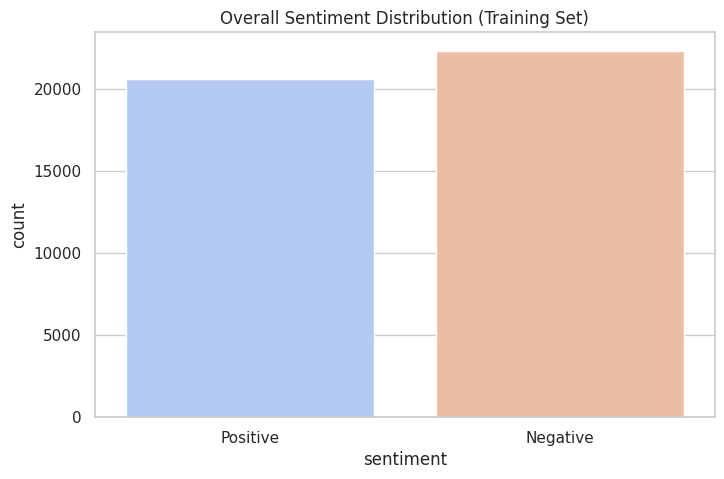

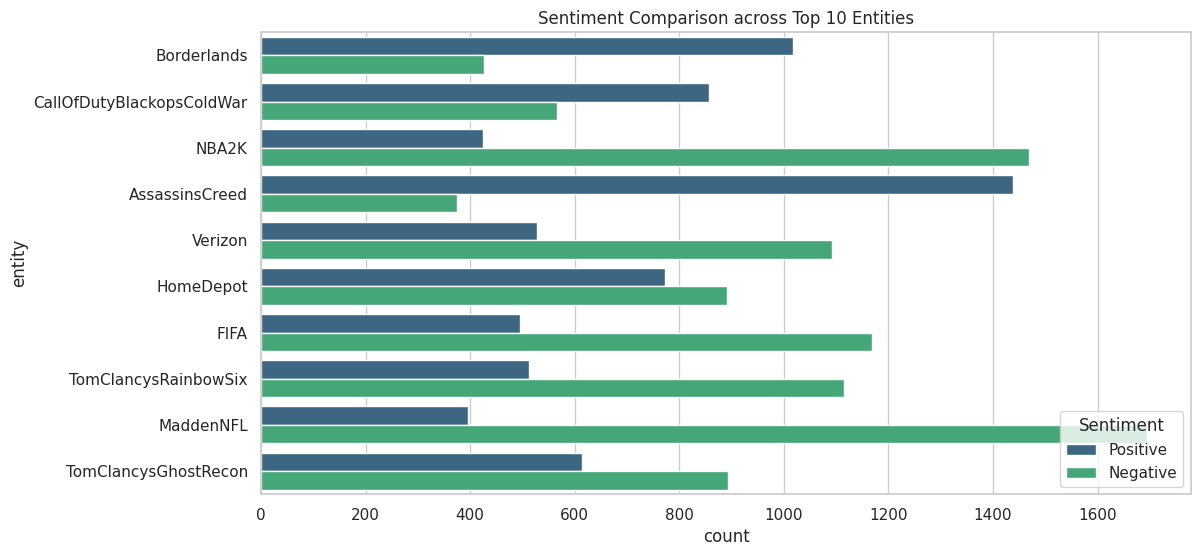

In [4]:
# Set visual style
sns.set(style="whitegrid")

# Plot 1: Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=train, x='sentiment', palette='coolwarm')
plt.title('Overall Sentiment Distribution (Training Set)')
plt.show()

# Plot 2: Sentiment across Top 10 Brands/Entities
top_10_entities = train['entity'].value_counts().head(10).index
subset = train[train['entity'].isin(top_10_entities)]

plt.figure(figsize=(12, 6))
sns.countplot(data=subset, y='entity', hue='sentiment', palette='viridis')
plt.title('Sentiment Comparison across Top 10 Entities')
plt.legend(title='Sentiment', loc='lower right')
plt.show()

# Model Training & Evaluation

In [5]:
# Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = tfidf.fit_transform(train['clean_text'])
y_train = train['sentiment']

X_valid = tfidf.transform(valid['clean_text'])
y_valid = valid['sentiment']

# Initialize and train the Naive Bayes Classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# Evaluation on Validation Data
preds = model.predict(X_valid)
print(f"Model Accuracy: {accuracy_score(y_valid, preds):.2%}")
print("\nClassification Report:")
print(classification_report(y_valid, preds))

Model Accuracy: 89.69%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.91      0.90       266
    Positive       0.91      0.88      0.90       277

    accuracy                           0.90       543
   macro avg       0.90      0.90      0.90       543
weighted avg       0.90      0.90      0.90       543



# Prediction

In [6]:
def classify_tweet(tweet):
    cleaned = clean_text(tweet)
    vec = tfidf.transform([cleaned])
    return model.predict(vec)[0]

# Example usage:
print(f"Sample Tweet Prediction: {classify_tweet('This game is so buggy and unplayable!')}")

Sample Tweet Prediction: Negative
